In [18]:
import numpy as np
import pandas as pd
import os
import sys

### Đọc dữ liệu

In [19]:
monthly_df = pd.read_csv("../data/strategy_04_monthly.csv")

In [20]:
monthly_df.head(5)

,m,revenue,cnt_cus,cnt_pro,cnt
0,2010-12-01,748957.020,948,2822,342228
1,2011-01-01,560000.260,783,2645,308966
2,2011-02-01,498062.650,798,2431,277989
3,2011-03-01,683267.080,1020,2562,351872
4,2011-04-01,493207.121,899,2558,289098


In [21]:
monthly_df = monthly_df.sort_values("m")

In [22]:
monthly_df.columns

Index(['m', 'revenue', 'cnt_cus', 'cnt_pro', 'cnt'], dtype='object')

### Phân tích

<Figure size 1200x500 with 0 Axes>

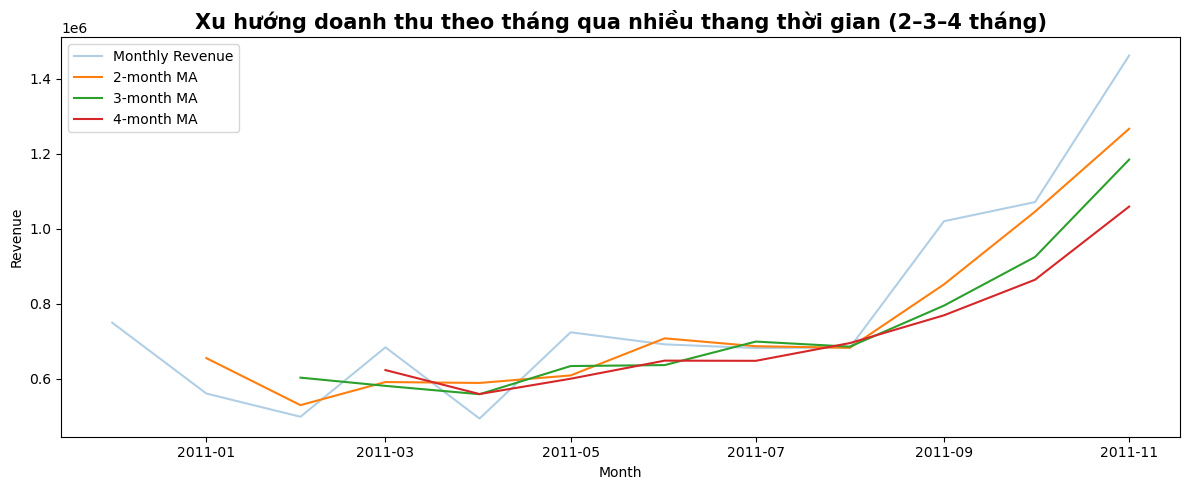

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# đảm bảo cột ngày đúng kiểu
monthly_df['m'] = pd.to_datetime(monthly_df['m'])
monthly_df = monthly_df.sort_values('m')

last_month = monthly_df['m'].max()

monthly_df = monthly_df[monthly_df['m'] < last_month]

# tính các moving averages
monthly_df['ma2'] = monthly_df['revenue'].rolling(window=2).mean()
monthly_df['ma3'] = monthly_df['revenue'].rolling(window=3).mean()
monthly_df['ma4'] = monthly_df['revenue'].rolling(window=4).mean()

plt.figure(figsize=(12, 5))

plt.figure(figsize=(12, 5))

# Doanh thu gốc theo tháng
sns.lineplot(
    data=monthly_df,
    x='m',
    y='revenue',
    label='Monthly Revenue',
    alpha=0.35
)

# Các đường trend baseline
sns.lineplot(data=monthly_df, x='m', y='ma2', label='2-month MA')
sns.lineplot(data=monthly_df, x='m', y='ma3', label='3-month MA')
sns.lineplot(data=monthly_df, x='m', y='ma4', label='4-month MA')

plt.title(
    'Xu hướng doanh thu theo tháng qua nhiều thang thời gian (2–3–4 tháng)',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.show()

#### Kiểm tra bằng OLS model

In [24]:
import statsmodels.api as sm

monthly_df['m'] = pd.to_datetime(monthly_df['m'])
monthly_df = monthly_df.sort_values('m')
monthly_df['t'] = range(len(monthly_df))

X = sm.add_constant(monthly_df['t'])
y = monthly_df['revenue']

model = sm.OLS(y, X).fit()

print(f"p-value (trend) = {model.pvalues['t']}")
print(model.summary())


p-value (trend) = 0.004928982444124153
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     12.89
Date:                Tue, 06 Jan 2026   Prob (F-statistic):            0.00493
Time:                        20:56:48   Log-Likelihood:                -162.01
No. Observations:                  12   AIC:                             328.0
Df Residuals:                      10   BIC:                             329.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4

C:\Users\phong\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


p-value < 0.05 --> Có trend --> Muốn tính seasonality thì phải khử trend trước.

t > 0: trend tăng.

#### Mann–Kendall Trend Test

In [25]:
!pip install pymannkendall

In [26]:
import pymannkendall as mk

result = mk.original_test(monthly_df['revenue'])

print(result)

Mann_Kendall_Test(trend='no trend', h=False, p=0.06410357671243583, z=1.8514587995741025, Tau=0.42424242424242425, s=28.0, var_s=212.66666666666666, slope=53182.637571428546, intercept=394690.593357143)


#### Khử trend

In [27]:
import statsmodels.api as sm
import pandas as pd

monthly_df = monthly_df.sort_values('m')
monthly_df['t'] = range(len(monthly_df))

X = sm.add_constant(monthly_df['t'])
y = monthly_df['revenue']

model = sm.OLS(y, X).fit()

monthly_df['trend_ols'] = model.predict(X)
monthly_df['rev_detrended'] = monthly_df['revenue'] - monthly_df['trend_ols']

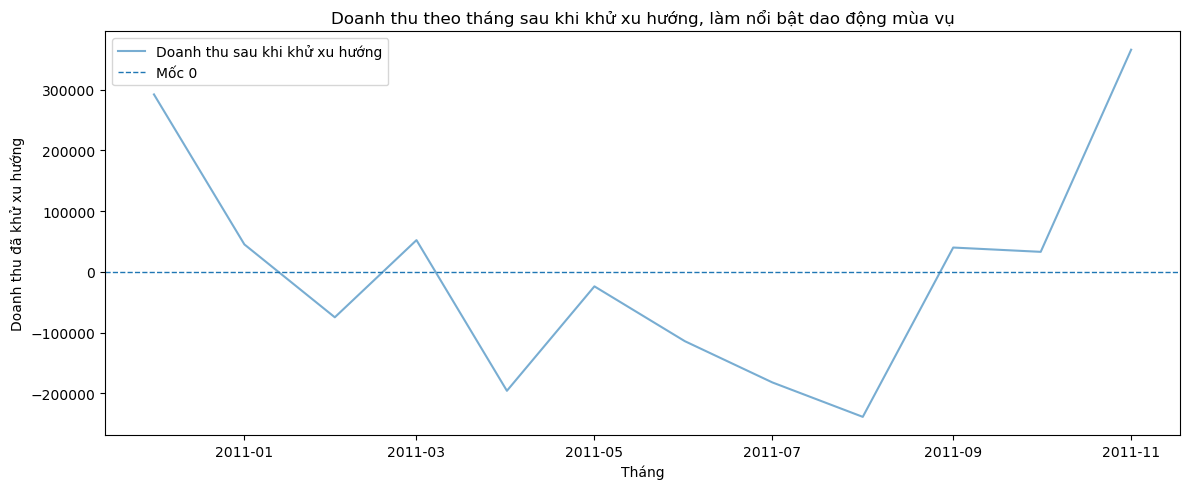

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_df,
    x='m',
    y='rev_detrended',
    label='Doanh thu sau khi khử xu hướng',
    alpha=0.6
)

plt.axhline(0, linestyle='--', linewidth=1, label='Mốc 0')

plt.title(
    'Doanh thu theo tháng sau khi khử xu hướng, làm nổi bật dao động mùa vụ',
    fontsize=12
)

plt.xlabel('Tháng')
plt.ylabel('Doanh thu đã khử xu hướng')
plt.legend()
plt.tight_layout()
plt.show()

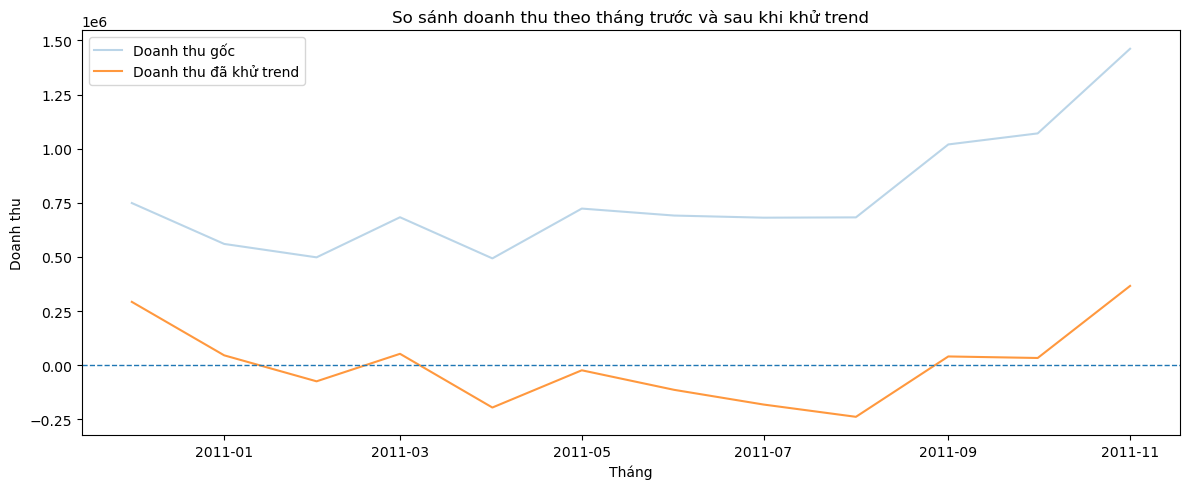

In [29]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_df,
    x='m',
    y='revenue',
    label='Doanh thu gốc',
    alpha=0.3
)

sns.lineplot(
    data=monthly_df,
    x='m',
    y='rev_detrended',
    label='Doanh thu đã khử trend',
    alpha=0.8
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title(
    'So sánh doanh thu theo tháng trước và sau khi khử trend',
    fontsize=12
)

plt.xlabel('Tháng')
plt.ylabel('Doanh thu')
plt.legend()
plt.tight_layout()
plt.show()

#### Tính seasonality theo tháng

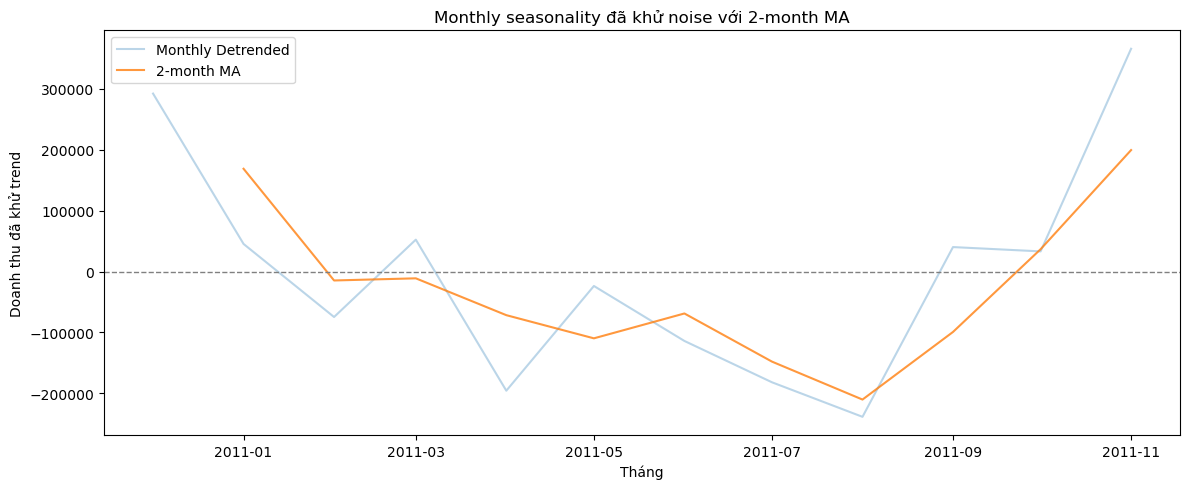

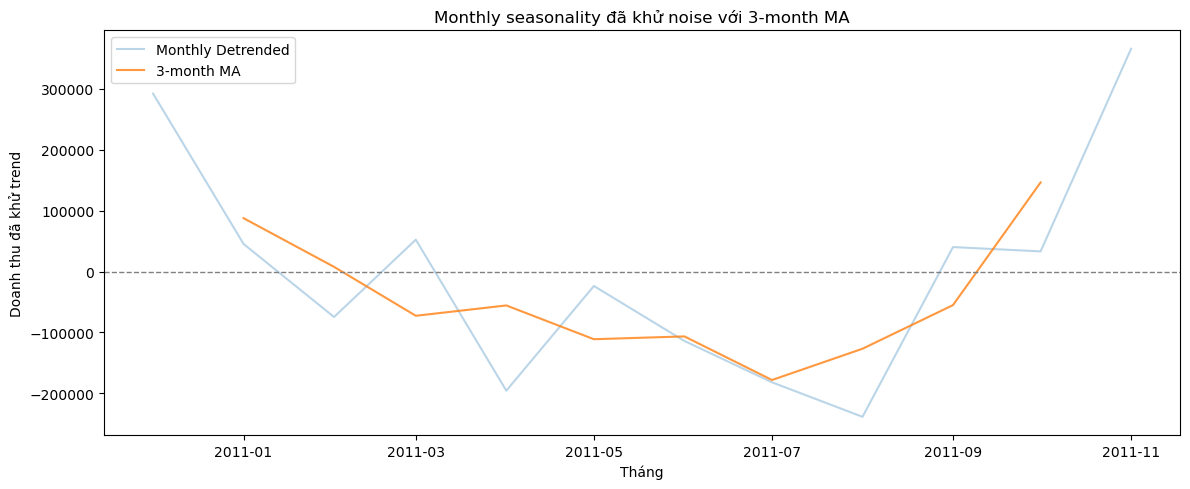

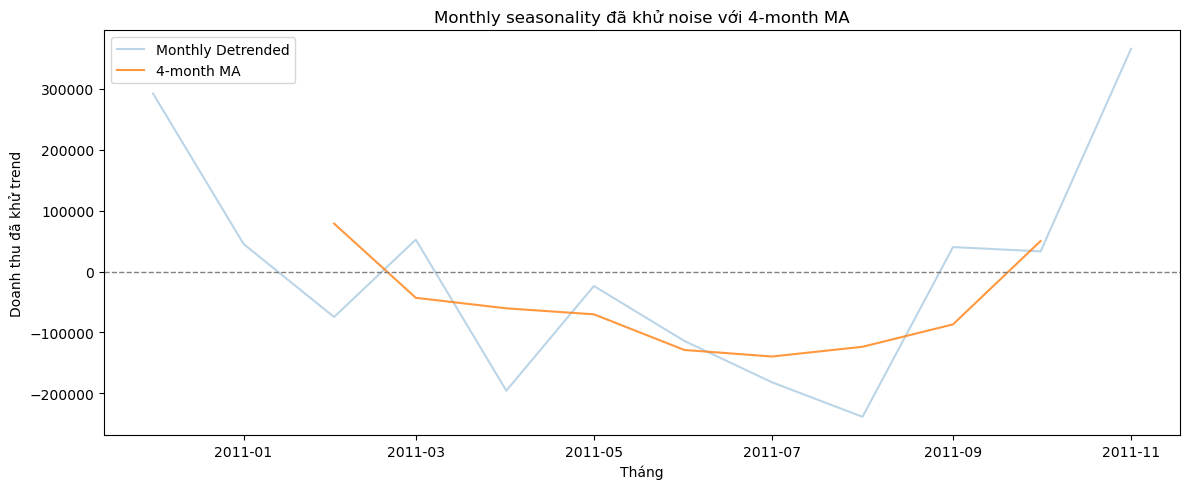

In [30]:
windows = [2, 3, 4]

# Tạo moving averages cho từng window
for w in windows:
    monthly_df[f'ma{w}'] = monthly_df['rev_detrended'].rolling(window=w, center=True).mean()

# Vẽ từng cặp
for w in windows:
    plt.figure(figsize=(12, 5))
    
    # Dữ liệu gốc
    sns.lineplot(data=monthly_df, x='m', y='rev_detrended', label='Monthly Detrended', alpha=0.3)
    
    # MA tương ứng
    sns.lineplot(data=monthly_df, x='m', y=f'ma{w}', label=f'{w}-month MA', alpha=0.8)
    
    plt.axhline(0, linestyle='--', linewidth=1, color='grey')
    plt.title(f"Monthly seasonality đã khử noise với {w}-month MA", fontsize=12)
    plt.xlabel("Tháng")
    plt.ylabel("Doanh thu đã khử trend")
    plt.legend()
    plt.tight_layout()
    plt.show()
